## Quantile binning

In this notebook, we work on discretizing treatment according to treatment dosage quantile, so that every discrete treatment level has the same number of samples.

In [1]:
import pandas as pd
import sys
sys.path.append("../../..")
import numpy as np
import torch
import matplotlib.pyplot as plt

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [2]:
## Synthetic data generation

data_name = "vahid-nonlinear"

np.random.seed(42)
n, d = 2000, 1
X = np.random.normal(2, 1, size=(n, d)).astype(np.float32)
T = (0.1 * X[:, 0] ** 2 - X[:, 0] + np.random.normal(1, 2, size=n)).astype(np.float32)
T = T - T.min() # Rescale
T = T / T.max() # Rescale
Y = (0.5 * T ** 2 - T * X[:, 0] + np.random.normal(0, 2, size=n)).astype(np.float32)
def drf(t): return 0.5 * t ** 2 - 2 * t # true dose-response funcion

df = pd.concat([
    pd.DataFrame(data=X, columns=["x"]), 
    pd.DataFrame(data=T, columns=["T"]), 
    pd.DataFrame(data=Y, columns=["Y"])
    ], axis=1)

In [3]:
# Discretization function
def discretize_treatment(T: np.ndarray, N: int) -> tuple[np.ndarray, np.ndarray]:
    """Returns quantile method discretized version of T. Assumes range of T is [0, 1].

    Args:
        T (np.ndarray): The raw treatment data 
        N (int): The number of bins (equiv to the number of discrete treatment values)

    Returns:
        np.ndarray: The discretized treatment data (expected outcomes)
        np.ndarray: The discretized treatment values
    """
    T_discrete = np.zeros(T.shape)
    T_vals = np.zeros((N,))
    bin_edges = np.percentile(T, np.linspace(0, 100, N + 1))
    for i in range(len(bin_edges) - 1):
        left_edge = bin_edges[i]
        right_edge = bin_edges[i + 1]
        ids = (T >= left_edge) & (T <= right_edge)
        avg = np.mean(T[ids])
        T_discrete[ids] = avg
        T_vals[i] = avg

    return T_discrete, T_vals

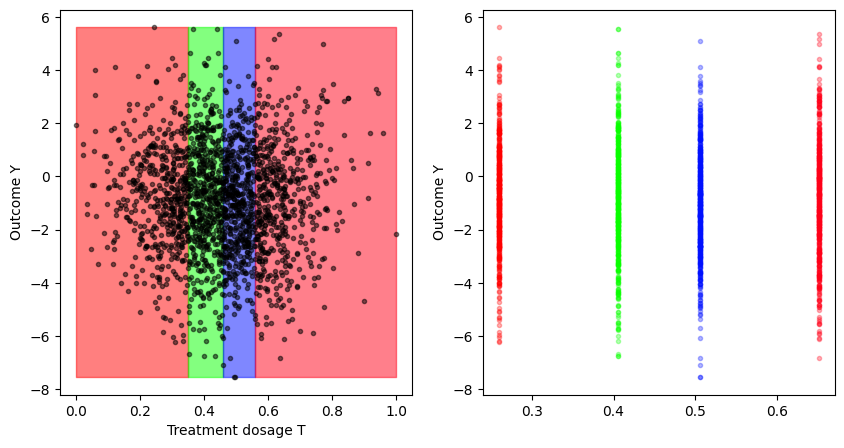

In [4]:
# Visualization of the discretization process. Change N_DISC below.
N_DISC = 4
T_discrete, T_vals = discretize_treatment(T, N_DISC)

bin_edges = np.percentile(T, np.linspace(0, 100, N_DISC + 1))
plt.figure(figsize=(10, 5))
c_map = plt.get_cmap("hsv", N_DISC) # new color for each discrete dosage 
i = 0
plt.subplot(1, 2, 1)
plt.plot(T, Y, '.', alpha=0.5, c="k") # plot the data
for idx in range(N_DISC):
    left_edge = bin_edges[i]
    right_edge = bin_edges[i + 1]
    ids = (T >= left_edge) & (T <= right_edge)
    avg = np.mean(T[ids])
    plt.fill_betweenx(y=[Y.min(), Y.max()], # plot the discrete treatment regions 
                      x1=left_edge, 
                      x2=right_edge,
                      color=c_map(i), alpha=0.5)
    i += 1
plt.xlabel("Treatment dosage T")
plt.ylabel("Outcome Y")

plt.subplot(1, 2, 2)
i = 0
for idx in range(N_DISC):
    left_edge = bin_edges[i]
    right_edge = bin_edges[i + 1]
    ids = (T >= left_edge) & (T <= right_edge)
    avg = np.mean(T[ids])
    plt.plot(T_discrete[ids], Y[ids], '.', alpha=0.3, c=c_map(i))
    i += 1
plt.ylabel("Outcome Y")

plt.show()

In [5]:
print(f"T_vals: {T_vals}")

T_vals: [0.2593258  0.40509784 0.50552189 0.65110511]


In [6]:
# Verify evenly-distributed
for val in np.unique(T_discrete):
    ids = (T_discrete == val)
    print(f"# samples discretized to {val:.3f}: {ids.sum()}")

# samples discretized to 0.259: 500
# samples discretized to 0.405: 500
# samples discretized to 0.506: 500
# samples discretized to 0.651: 500
